<a href="https://colab.research.google.com/github/cansinmeltemkalayci/Okun-s-Law-Output-Growth-and-Unemployment/blob/main/okuns_law__finalproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***OKUN'S LAW: OUTPUT GROWTH AND UNEMPLOYMENT***

## Research question:
#### Does Okun's law hold in the US? When GDP grows faster, does unemployment fall? And by how much? Has the relationship changed across decades?

### Okun's law (difference version):
### $\Delta u_t = \alpha + \beta g_t + \varepsilon_t$

## Section 1: data loading and first look

### First thing first we import the needed packages

In [ ]:
import statsmodels.api as sm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#### 1.1: Loading the dataset

In [ ]:
macro = sm.datasets.macrodata.load_pandas().data

In [ ]:
# Report of dataset's dimensions, column data types, a full summary of descriptive statistics and the first 5 raws
display('Dataset shape : ', macro.shape)
display('Dataset type : ', macro.dtypes )
display('Summary of descriptive statistics : ', macro.describe().round(2) )
display('First five rows : ', macro.head())

'Dataset shape : '

(203, 14)

'Dataset type : '

year        float64
quarter     float64
realgdp     float64
realcons    float64
realinv     float64
realgovt    float64
realdpi     float64
cpi         float64
m1          float64
tbilrate    float64
unemp       float64
pop         float64
infl        float64
realint     float64
dtype: object

'Summary of descriptive statistics : '

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
count,203.00,203.00,203.00,203.00,203.00,203.00,203.00,203.00,203.00,203.00,203.00,203.00,203.00,203.00
mean,1983.88,2.49,7221.17,4825.29,1012.86,663.33,5310.54,105.08,667.93,5.31,5.88,239.72,3.96,1.34
std,14.69,1.12,3214.96,2313.35,585.10,140.86,2423.52,61.28,455.35,2.80,1.46,37.39,3.25,2.67
min,1959.00,1.00,2710.35,1707.40,259.76,460.40,1886.90,28.98,139.60,0.12,3.40,177.15,-8.79,-6.79
25%,1971.00,1.50,4440.10,2874.10,519.15,527.96,3276.95,41.05,228.65,3.51,4.90,208.63,2.27,-0.08
50%,1984.00,2.00,6559.59,4299.90,896.21,662.41,4959.40,104.10,540.90,5.01,5.70,236.35,3.24,1.34
75%,1996.50,3.00,9629.35,6398.15,1436.68,773.05,6977.85,159.65,1102.10,6.66,6.80,271.72,4.97,2.63
max,2009.00,4.00,13415.27,9363.60,2264.72,1044.09,10077.50,218.61,1673.90,15.33,10.70,308.01,14.62,10.95


'First five rows : '

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
0,1959.0,1.0,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00
1,1959.0,2.0,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74
2,1959.0,3.0,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09
3,1959.0,4.0,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06
4,1960.0,1.0,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19


#### 1.2: Assignment of a quarter DatetimeIndex

In [ ]:
# Creation of the quarterly index (quarter start)
dates = pd.date_range(start='1959-01-01', periods=int(len(macro)), freq='QS')

# Assigning the index to the dataframe and naming it
macro.index = dates
macro.index.name = 'quarter period'

macro.head()

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
quarter period,,,,,,,,,,,,,,
1959-01-01,1959.0,1.0,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00
1959-04-01,1959.0,2.0,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74
1959-07-01,1959.0,3.0,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09
1959-10-01,1959.0,4.0,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06
1960-01-01,1960.0,1.0,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19


#### 1.3: Checking every column for missing values

In [ ]:
macro.isna().sum()

year        0
quarter     0
realgdp     0
realcons    0
realinv     0
realgovt    0
realdpi     0
cpi         0
m1          0
tbilrate    0
unemp       0
pop         0
infl        0
realint     0
dtype: int64

0 NA in the dataset

## Section 2: Data preparation

#### 2.1: Constructing `gdp_growt` [$ 400 * \Delta ln (realgdp_t) $] and `d_unemp`  [$ \Delta unemp_t $]  series


In [ ]:
macro["gdp_growth"] = 400 * np.log(macro['realgdp']).diff()
macro["d_unemp"] = macro['unemp'].diff()

#### 2.2: Removing missing values introduced by the above transformations

In [ ]:
macro_nonan = macro.dropna()

# Checking how the dataset changed after dropping NaNs
print(f'Shape of macro (after transformations): {macro.shape}')
print()
print(f'Shape of macro (after transformations) without NaNs: {macro_nonan.shape} ')

Shape of macro (after transformations): (203, 16)

Shape of macro (after transformations) without NaNs: (202, 16) 


Just one raw was removed, the first one, due to the .diff() tranformation.

### 2.3: Creating a decade column assigning each observation to its decade

In [ ]:
# Removing 'year' and 'quarter' columns
macro_d = macro_nonan.drop(columns = ['year', 'quarter'])

# Creating and assigning the decade column to the dataset
macro_d['decade'] = (macro_d.index.year // 10 * 10).astype(str)
macro_d.head(8)

,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint,gdp_growth,d_unemp,decade
quarter period,,,,,,,,,,,,,,,
1959-04-01,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74,9.976852,-0.7,1950
1959-07-01,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09,-0.477181,0.2,1950
1959-10-01,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06,1.397813,0.3,1950
1960-01-01,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19,8.876072,-0.4,1960
1960-04-01,2834.390,1792.9,298.152,460.400,1966.1,29.55,140.2,2.68,5.2,180.671,0.14,2.55,-1.873821,0.0,1960
1960-07-01,2839.022,1785.8,296.375,474.676,1967.8,29.75,140.9,2.36,5.6,181.528,2.70,-0.34,0.653152,0.4,1960
1960-10-01,2802.616,1788.2,259.764,476.434,1966.6,29.84,141.1,2.29,6.3,182.287,1.21,1.08,-5.162544,0.7,1960
1961-01-01,2819.264,1787.7,266.405,475.854,1984.5,29.81,142.1,2.37,6.8,182.992,-0.40,2.77,2.369037,0.5,1960


## Section 3: Exploratory Data Analysis

#### 3.1: Subplots for `unemp` and `d_unemp` with shaded NBER recession periods

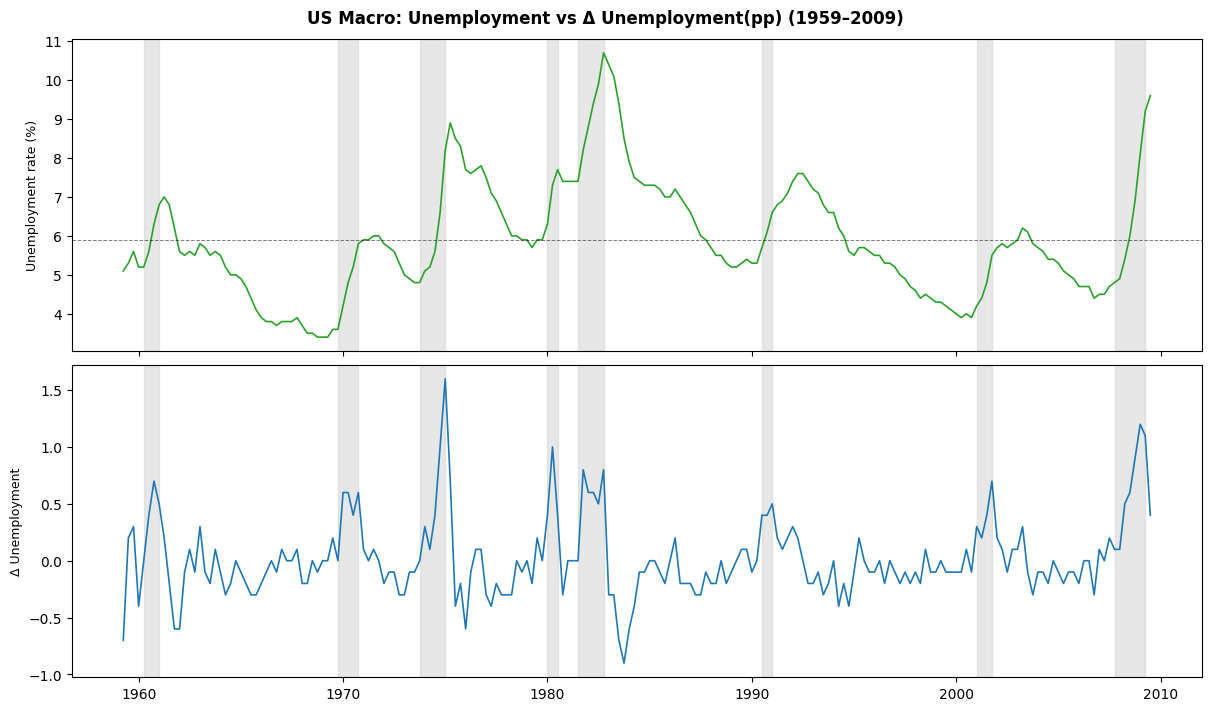

In [ ]:
# Defining NBER recession periods as a list of tuples
recessions = [
    ('1960-04-01', '1961-01-01'), ('1969-10-01', '1970-10-01'), ('1973-10-01', '1975-01-01'),
    ('1980-01-01', '1980-07-01'), ('1981-07-01', '1982-10-01'), ('1990-07-01', '1991-01-01'),
    ('2001-01-01', '2001-10-01'), ('2007-10-01', '2009-04-01'),
]

# Defining a function "add_recession_shading"
def add_recession_shading(ax, recessions=recessions):
    """Shades NBER recession periods on a matplotlib Axes"""
    for start, end in recessions:                               # for each couple in recessions it creates a vertical shaded band
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),      # taking all the height of the plot
                   color='#d0d0d0', alpha=0.5, zorder=0)

# Creating a figure of dimensions (2 x 1) containing both plots, sharing the same X axis
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, constrained_layout=True)
series = [('unemp',      'Unemployment rate (%)', '#2ca02c', True),
          ('d_unemp', 'Δ Unemployment', '#1f77b4', False)]

# Using a for loop to create both plots and adding the shaded bands in recession periods
for ax, (col, label, color, zeroline) in zip(axes, series):
    add_recession_shading(ax)
    ax.plot(macro_d.index, macro_d[col], color=color, linewidth=1.2)
    ax.set_ylabel(label, fontsize=9)
    if zeroline:
        ax.axhline(macro_d[col].mean(),color='black',linewidth=0.7, linestyle='--', alpha=0.5)

# Plots title
fig.suptitle('US Macro: Unemployment vs Δ Unemployment(pp) (1959–2009)',
             fontsize=12, fontweight='bold')

plt.show()

Recession periods always correspond to increasing Unemployment rate periods and mainly to increasing $\Delta Unemployment$  periods. Unemployment  rate travels around his mean, which is slightly below 6%.

#### 3.2: Scatter plot of `d_unemp` against `gdp_growt` with observations coloured by decade

/var/folders/07/y79kvbg50jl5381hlnws_9880000gn/T/ipykernel_11570/3503475493.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(decades))


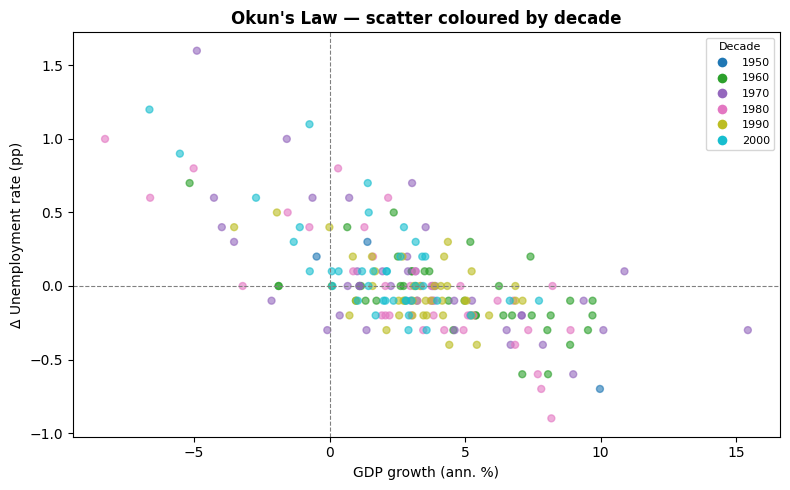

In [ ]:
from matplotlib.lines import Line2D

# Creating a decade list with unique values
decades = sorted(macro_d['decade'].unique())
# Transforming 'decades' in a categorical variable ordered by decades and the in a integers array
cat_codes = pd.Categorical(macro_d['decade'], categories=decades).codes
# Creating a color map with a color for each decade
cmap = plt.cm.get_cmap('tab10', len(decades))

# Creating a figure contaning the plot
fig, ax = plt.subplots(figsize=(8, 5))

# Creating the scatter plot with colors divided by decade
sc = ax.scatter(macro_d['gdp_growth'], macro_d['d_unemp'],
                c=cat_codes, cmap=cmap, alpha=0.6, s=25, zorder=2)
# Adding 0 reference line for both axes
ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.8, linestyle='--')
# Axes lables and plot's title
ax.set_xlabel('GDP growth (ann. %)')
ax.set_ylabel('Δ Unemployment rate (pp)')
ax.set_title("Okun's Law — scatter coloured by decade", fontweight='bold')

handles = [Line2D([0],[0], marker='o', color='w',
                  markerfacecolor=cmap(i), markersize=8, label=d)
           for i, d in enumerate(decades)]
ax.legend(handles=handles, title='Decade', fontsize=8, title_fontsize=8)

plt.tight_layout()
plt.show()

As we would expect the cloud is tilted downward, meaning that when the economy grows (high `gdp_growth`) unemployment falls (negative `d_unemp`)

### 3.3: Table contaning mean of `gdp_growth`' and `d_unemp` and the correlation between the two

In [ ]:
agg = macro_d.groupby('decade').agg(
    avg_gdp_g = ('gdp_growth', 'mean'),
    avg_d_unemp = ('d_unemp', 'mean'),
    correlation = ('gdp_growth', lambda x: x.corr(macro_d.loc[x.index, 'd_unemp']))
)
display(agg.round(2))

,avg_gdp_g,avg_d_unemp,correlation
decade,,,
1950,3.63,-0.07,-0.97
1960,4.26,-0.05,-0.62
1970,3.23,0.06,-0.62
1980,2.99,-0.01,-0.81
1990,3.27,-0.03,-0.53
2000,1.69,0.14,-0.71


### 3.4: Histogram of `d_unemp`

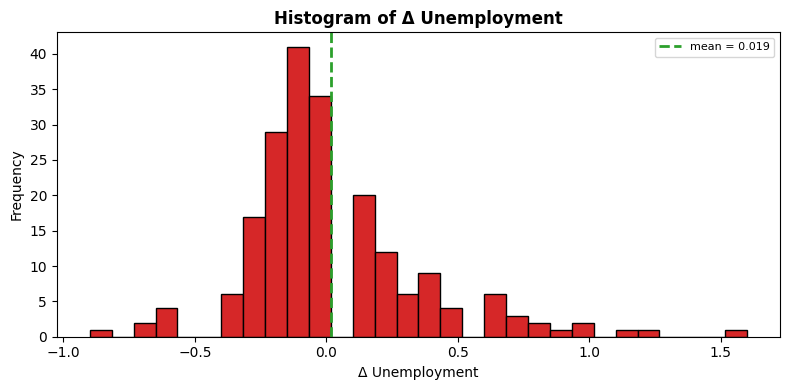

Fraction of quarters with rising unemployment: 33.663%
Fraction of quarters with falling or stationary unemployment: 66.337%


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

# Creating an histogram of 'd_unemp' divided in 30 vertical bars
ax.hist(macro_d['d_unemp'], bins=30, color='#d62728', edgecolor='black')
# Adding a vertical line in correspondence of 'd_unemp' mean
ax.axvline(macro_d['d_unemp'].mean(), color='#2ca02c', linewidth=2, linestyle='--', label=f'mean = {macro_d['d_unemp'].mean():.3f}')

ax.set_xlabel('Δ Unemployment')
ax.set_ylabel('Frequency')
ax.set_title('Histogram of Δ Unemployment', fontweight='bold')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Fraction of quarters where unemployment rose
frac_positive = ((macro_d['d_unemp'] > 0).mean()) * 100
frac_negative = ((macro_d['d_unemp'] <= 0).mean()) * 100
print(f"Fraction of quarters with rising unemployment: {frac_positive:.3f}%")
print(f"Fraction of quarters with falling or stationary unemployment: {frac_negative:.3f}%")

The histogram of `d_unemp`is left-skewed. This means that the largest single quarter moves are drops in `d_unemp`, while spikes of recessions (increasing `d_unemp`) are more frequent, but individually more moderate in magnitude.

## Section 4

#### 4.1: Okun's law OLS estimation using NumPy only

In [ ]:
# Defining an 'ols_estimate' function
def ols_estimate(y, X, add_constant=True):
    """
    OLS estimation with homoscedastic standard errors.

    Parameters
    ----------
    y : array_like, shape (T,)
        Dependent variable.
    X : array_like, shape (T, k) or (T,)
        Regressors. Do NOT include a column of ones unless add_constant=False.
    add_constant : bool
        If True, prepend a column of ones (intercept).

    Returns
    -------
    dict with keys beta, se, t_stat, resid, sigma2, r_squared.
    """
    # Normalise shapes
    y = np.asarray(y).flatten()
    X = np.asarray(X)
    if X.ndim == 1:
        X = X.reshape(-1, 1)

    # Add the intercept column if requested
    if add_constant:
        X = np.column_stack([np.ones(X.shape[0]), X])

    T, k = X.shape

    # β̂ = (X'X)⁻¹ X'y
    XtX_inv = np.linalg.inv(X.T @ X)
    beta    = np.linalg.solve(X.T @ X, X.T @ y)

    # Residuals and σ̂²
    resid  = y - X @ beta
    sigma2 = (resid @ resid) / (T - k)

    # Standard errors and t-statistics
    se     = np.sqrt(np.diag(sigma2 * XtX_inv))
    t_stat = beta / se

    # R²
    ss_tot    = np.sum((y - y.mean()) ** 2)
    r_squared = 1 - (resid @ resid) / ss_tot

    return {'beta': beta, 'se': se, 't_stat': t_stat,
            'resid': resid, 'sigma2': sigma2, 'r_squared': r_squared}

# Running the regression on 'd_unemp' and 'gdp_growth'
res = ols_estimate(macro_d['d_unemp'], macro_d['gdp_growth'], add_constant=True)
alpha_hat = res['beta'][0]
beta_hat = res['beta'][1]
RES = np.sqrt(res['sigma2'])

# Results table
print('  alpha_hat    |     beta_hat    |     R^2    |   RES   ')
print('-'*60)
print(f"  {alpha_hat:+.4f}      |     {beta_hat:+.4f}     |   {round(res['r_squared'],4)}   |   {RES:.4f}")

  alpha_hat    |     beta_hat    |     R^2    |   RES   
------------------------------------------------------------
  +0.2271      |     -0.0671     |   0.4711   |   0.2509


#### 4.2: statsmodel OLS regression for each decade

,beta_hat,se
decade,,
1960s,-0.0448,0.0093
1970s,-0.0596,0.0122
1980s,-0.0827,0.0098
1990s,-0.0500,0.0129
2000s,-0.0936,0.0151


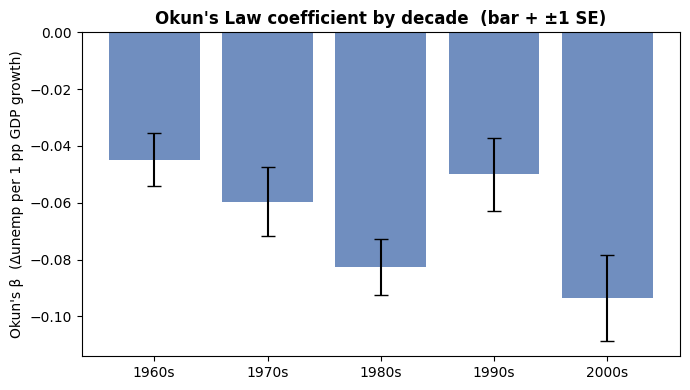

In [ ]:
# Creating a reduced dataset with only the variables we need
red = macro_d[['d_unemp', 'gdp_growth', 'decade']]

# Creating empty lists to be filled
betas, ses, dec_labels = [], [], []

# Running OLS for each decade
for decade, grp in red.groupby('decade'):
    if len(grp) < 8:
        continue
    X_d = sm.add_constant(grp['gdp_growth'])
    r = sm.OLS(grp['d_unemp'], X_d).fit()
    betas.append(r.params['gdp_growth'])
    ses.append(r.bse['gdp_growth'])
    dec_labels.append(decade + 's')

# Converting lists in arrays
betas = np.array(betas)
ses = np.array(ses)
xpos = np.arange(len(dec_labels))

# Results table
results_table = pd.DataFrame({'decade' : dec_labels,
                              'beta_hat' : betas,
                              'se' : ses}).set_index('decade')
display(results_table.round(4))

# Barchart with error bars
fig, ax = plt.subplots(figsize=(7, 4))

bars = ax.bar(xpos, betas, yerr=ses, capsize=5,
              color='#4c72b0', alpha=0.8, error_kw={'elinewidth': 1.5})

ax.set_ylabel("Okun's β  (Δunemp per 1 pp GDP growth)")
ax.set_title("Okun's Law coefficient by decade  (bar + ±1 SE)", fontweight='bold')

ax.set_xticks(xpos)
ax.set_xticklabels(dec_labels)

plt.tight_layout()
plt.show()

## Section 5: Simulation

#### 5.1: 200 simulation per scenario

In [ ]:
# Set the seed
np.random.seed(42)

# Defining an 'okuns_simulation' function
def okuns_simulation(alpha, beta, g, sigma, u0, T=20, n_sims=200):
    """
    Simulate unemployment paths using the estimated Okun equation.
    u_t = u_{t-1} + alpha + beta*g + eps,  eps ~ N(0, sigma)

    Parameters
    ----------
    alpha, beta : floats from the OLS in Section 4.1
    g     : GDP growth rate (in the same % pt units as gdp_growth series)
    sigma : residual standard error (RES from Section 4.1)
    u0    : last observed unemployment rate
    T     : forecast horizon (quarters)
    n_sims: number of replications

    Returns
    -------
    sims : ndarray, shape (n_sims, T)
    """
    sims = np.zeros((n_sims, T))
    for s in range(n_sims):
        u_prev = u0
        eps = np.random.normal(0, sigma, size=T)
        for t in range(T):
            u_curr = u_prev + alpha + beta * g + eps[t]
            sims[s, t] = u_curr
            u_prev = u_curr
    return sims

# Defining the three scenarios
scenarios = {
    'optimistic': 3.0,
    'baseline':   1.5,
    'recession': -1.0,
}

# Defining the variables
u0     = macro_d['unemp'].iloc[-1]
T      = 20
n_sims = 200

# Creating an empty dictionary to be filled
all_sims = {}

# Running the simulation for each scenario
for name, g in scenarios.items():
    all_sims[name] = okuns_simulation(
        alpha=alpha_hat, beta=beta_hat,
        g=g, sigma=RES, u0=u0, T=T, n_sims=n_sims
    )

# Dictionary to store summary statistics
all_sims_summary = {}

# Computing median and 10th-90th percentiles and reporting them into a table
for name, sims in all_sims.items():
    sims_ext = np.column_stack([np.full(sims.shape[0], u0), sims])
    median = np.percentile(sims_ext, 50, axis=0)   # shape (21,) — includes t=0
    q10    = np.percentile(sims_ext, 10, axis=0)
    q90    = np.percentile(sims_ext, 90, axis=0)
     # Store the results
    all_sims_summary[name] = {'median': median, 'q10': q10, 'q90': q90}
    print(f"{'h':>3}  {'scenario':<12}  {'median':>8}  {'q10':>10}  {'q90':>10}")
    print("-" * 50)
    for h in [4, 8, 12, 16, 20]:
        print(f"{h:>3}  {name:<12}  {median[h]:>8.2f}  {q10[h]:>10.2f}  {q90[h]:>10.2f}")
    print()

  h  scenario        median         q10         q90
--------------------------------------------------
  4  optimistic        9.74        9.09       10.34
  8  optimistic        9.81        8.88       10.64
 12  optimistic        9.93        8.89       10.87
 16  optimistic       10.06        8.87       11.34
 20  optimistic       10.18        8.80       11.68

  h  scenario        median         q10         q90
--------------------------------------------------
  4  baseline         10.09        9.47       10.81
  8  baseline         10.66        9.71       11.43
 12  baseline         11.12       10.06       12.14
 16  baseline         11.60       10.33       12.74
 20  baseline         12.01       10.49       13.53

  h  scenario        median         q10         q90
--------------------------------------------------
  4  recession        10.74       10.07       11.24
  8  recession        11.90       11.09       12.71
 12  recession        13.18       12.12       14.06
 16  recessio

#### 5.2: Median paths plot with uncertainty bands

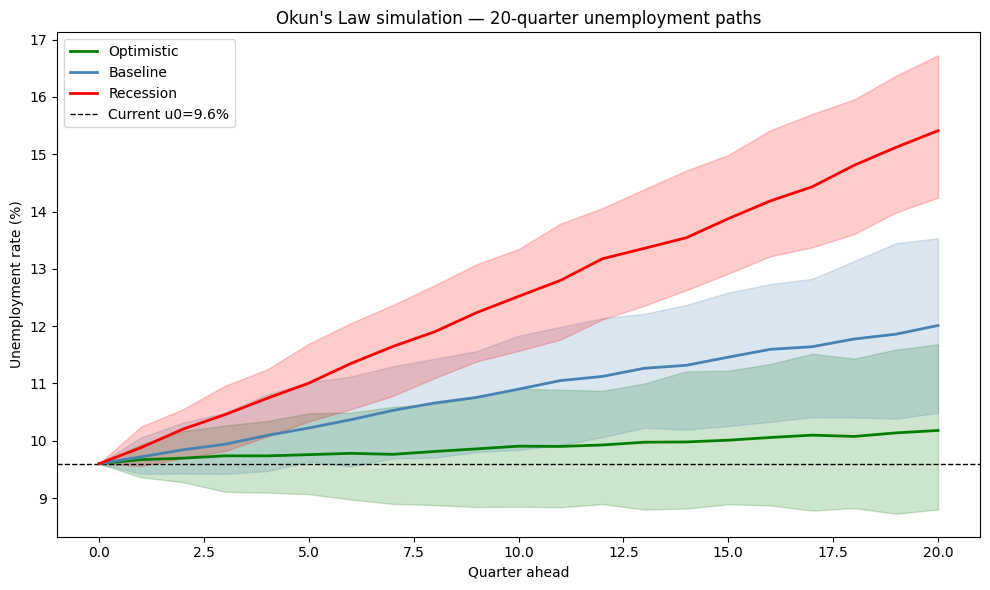

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

quarters = np.arange(0, T + 1)
colors   = {'optimistic': 'green', 'baseline': 'steelblue', 'recession': 'red'}

for name, sims in all_sims_summary.items():
    med = all_sims_summary[name]['median']
    q10 = all_sims_summary[name]['q10']
    q90 = all_sims_summary[name]['q90']
    col = colors[name]

    ax.plot(quarters, med, label=name.capitalize(), color=col, linewidth=2, zorder=3)
    ax.fill_between(quarters, q10, q90, color=col, alpha=0.2)

ax.axhline(u0, linestyle='--', color='black', linewidth=1, label=f'Current u0={u0:.1f}%')
ax.set_xlabel('Quarter ahead')
ax.set_ylabel('Unemployment rate (%)')
ax.set_title("Okun's Law simulation — 20-quarter unemployment paths")
ax.legend()
plt.tight_layout()
plt.show()

## Section 6: Wrap-Up


***EDA:***\
The time series (Section 3.1) confirms that unemployment grows consistently during NBER recessions and recovers slowly during expansions, a pattern visible in every recession from 1960 to 2009.
Across the full sample, unemployment rose in only 33.7% of quarters while in the remaining 66.3% it either fell or did not change at all, quantifying the asymmetry between contractions and expansions.
The scatter plot (Section 3.2) shows a clear negative cloud tilted from top-left to bottom-right, consistent with Okun's Law: higher GDP growth is associated with falling unemployment.
The decade-level summary (Section 3.3) confirms a negative correlation in every decade, ranging from −0.53 in the 1990s to −0.81 in the 1980s, already hinting at instability in the relationship over time.

***Okun's Law:***\
The full-sample NumPy OLS (Section 4.1) yields $\hat{\alpha}$ = +0.227, $\hat{\beta}$ = −0.067, and $R^2$ = 0.47, confirming that Okun's Law holds: a 1 percentage-point increase in GDP growth is associated with a 0.067 pp fall in unemployment on average.
The residual standard error (RES = 0.251) captures the substantial quarter-to-quarter noise around this relationship.
The per-decade statsmodels regressions (Section 4.2) reveal that $\hat{\beta}$ is not stable: it ranges from −0.045 in the 1960s to −0.094 in the 2000s, with the 1960s showing the weakest response ($\hat{\beta}$ = -0,0448) and the 1980s and 2000s the strongest ($\hat{\beta}$ = -0,0827 and $\hat{\beta}$ = -0,0936 rispectively).

***Simulations:***\
Starting from the 2009 Q3 unemployment rate of 9.6%, the simulation above (200 paths, 20 quarters) projects three clearly distinct trajectories.
Under the optimistic scenario (g = +3.0%), the median path stabilises near 10.2% with a relatively tight 10th–90th percentile band of 8.8%–11.7% at quarter 20.
Under the baseline scenario (g = +1.5%), the median rises to 12.0% by quarter 20, showing that moderate growth is insufficient to reverse an unemployment spike from an already elevated level.
Under the recession scenario (g = −1.0%), the median reaches 15.4% by quarter 20, with the 90th-percentile fan reaching 16.7%, illustrating how a downturn compounds an already critical situation.
Taken together, the simulations underscore the central policy implication of Okun's Law: reducing unemployment from a high baseline requires sustained GDP growth.